# Calibration error in seasonal months (backtest ECE > 0.08)



In [ ]:
import ast
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path("..").resolve()
sys.path[:0] = [str(PROJECT_ROOT / "src"), str(PROJECT_ROOT / "src" / "features"), str(PROJECT_ROOT / "src" / "models")]
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}")
import backtest  
%matplotlib inline

BACKTEST_ID = "backtest_brand64_2026-10-06_1791391493"
SCENARIOS = PROJECT_ROOT / "data/02_intermediate/backtest" / BACKTEST_ID
ECE_LIMIT = 0.08
FAIL, OK, GREY = "#b0413e", "#1e6b57", "#9aa6a1"

## 1. The backtest, month by month

For each test month: the month the probability was calibrated on, the churn rate of both, the mean predicted probability, the ECE and the AUC.

In [26]:
runs = mlflow.search_runs(
    experiment_names=["whizdom-churn-training"],
    filter_string=f"tags.backtest_id = '{BACKTEST_ID}' and tags.role = 'optimised' and params.model_id = 'lightgbm_classifier'")
bt = pd.DataFrame({
    "test_month": pd.to_datetime(runs["tags.test_cutoff"]),
    "valid_month": pd.to_datetime(runs["params.valid_cutoffs"].map(lambda v: ast.literal_eval(v)[0])),
    "valid_churn": runs["metrics.valid_churn_rate"],
    "test_churn": runs["metrics.test_churn_rate"],
    "mean_prediction": runs["metrics.test_calibrated_mean_prediction"],
    "ece": runs["metrics.test_calibrated_ece"],
    "auc": runs["metrics.test_calibrated_roc_auc"],
    "run_id": runs["run_id"],
}).sort_values("test_month").reset_index(drop=True)
bt["months_behind"] = ((bt["test_month"] - bt["valid_month"]).dt.days / 30.4).round().astype(int)
bt["fails"] = bt["ece"] > ECE_LIMIT
bt.drop(columns="run_id").round(3)

,test_month,valid_month,valid_churn,test_churn,mean_prediction,ece,auc,months_behind,fails
0,2025-10-01,2025-08-01,0.407,0.392,0.416,0.024,0.892,2,False
1,2025-11-01,2025-09-01,0.379,0.470,0.420,0.050,0.884,2,False
2,2025-12-01,2025-10-01,0.392,0.506,0.414,0.092,0.851,2,True
3,2026-01-01,2025-11-01,0.470,0.503,0.521,0.019,0.864,2,False
4,2026-02-01,2025-12-01,0.506,0.379,0.481,0.102,0.881,2,True
5,2026-03-01,2025-12-01,0.506,0.367,0.471,0.104,0.877,3,True
6,2026-04-01,2026-01-01,0.503,0.373,0.437,0.065,0.865,3,False
7,2026-05-01,2026-03-01,0.367,0.356,0.360,0.030,0.855,2,False
8,2026-06-01,2026-04-01,0.373,0.381,0.357,0.026,0.876,2,False
9,2026-07-01,2026-05-01,0.356,0.295,0.321,0.034,0.886,2,False


## 2. The churn rate moves with the season

Share of the active players (a bet in the 30 days before the date) with no bet in the next 60 days.

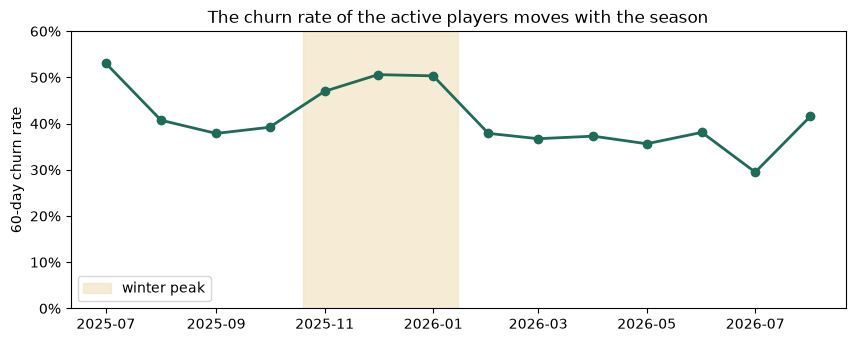

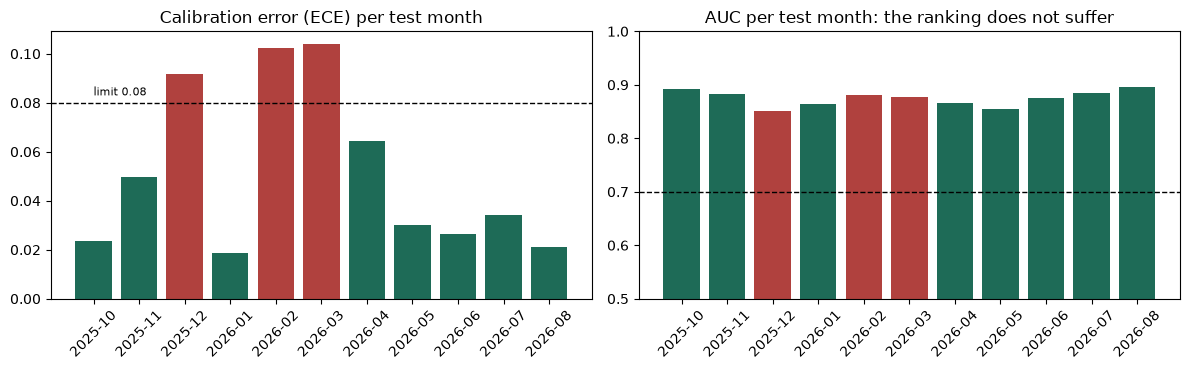

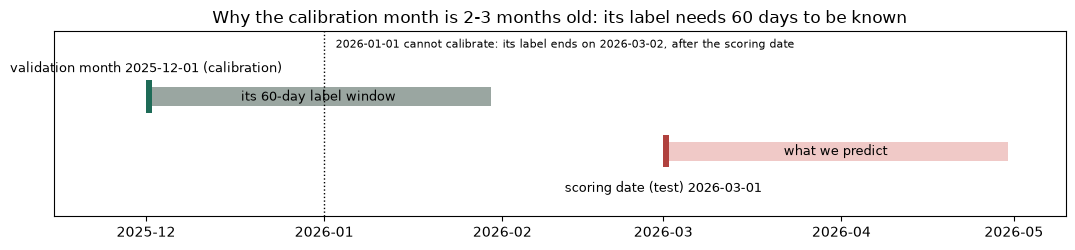

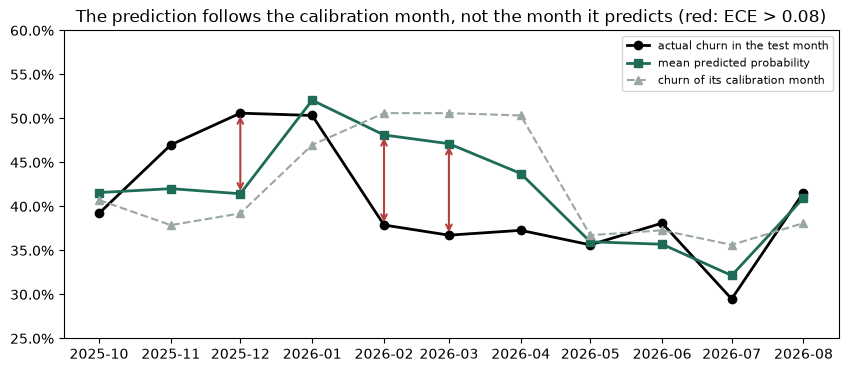

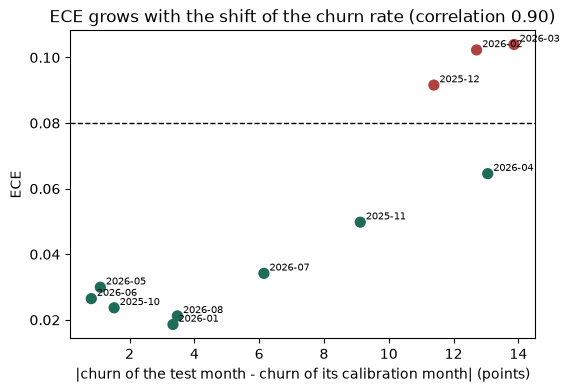

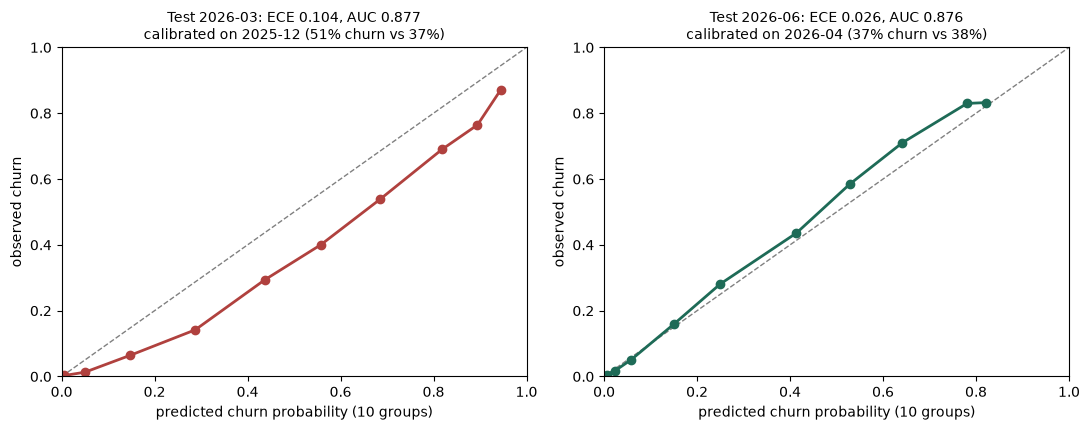

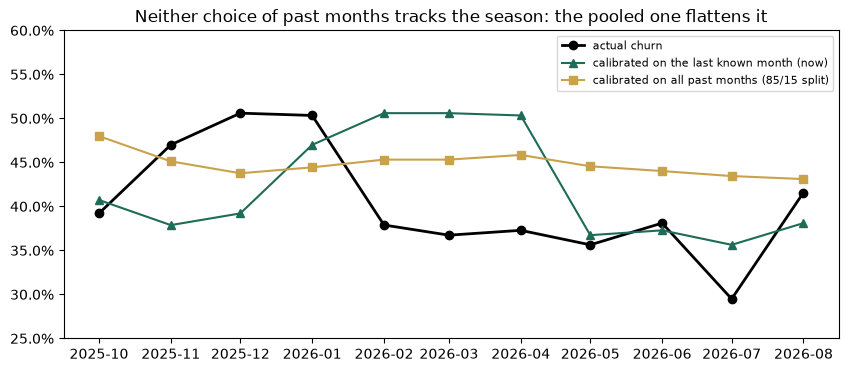

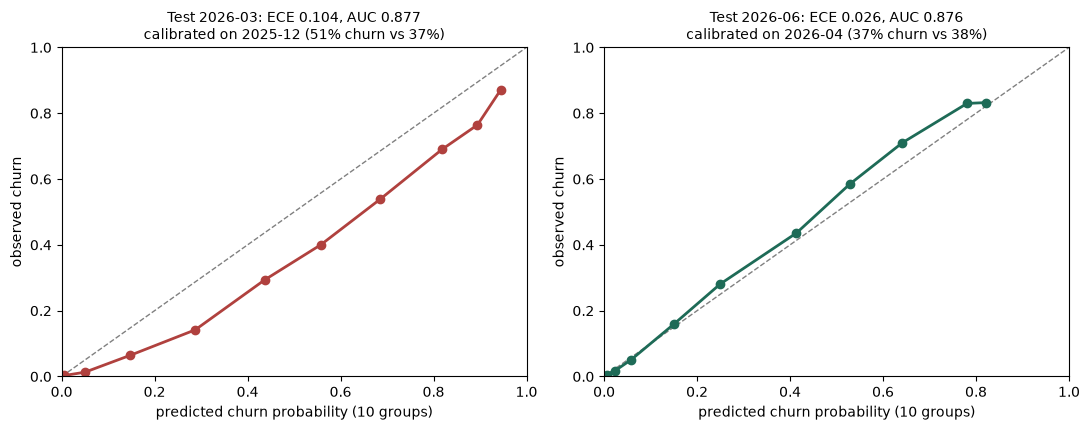

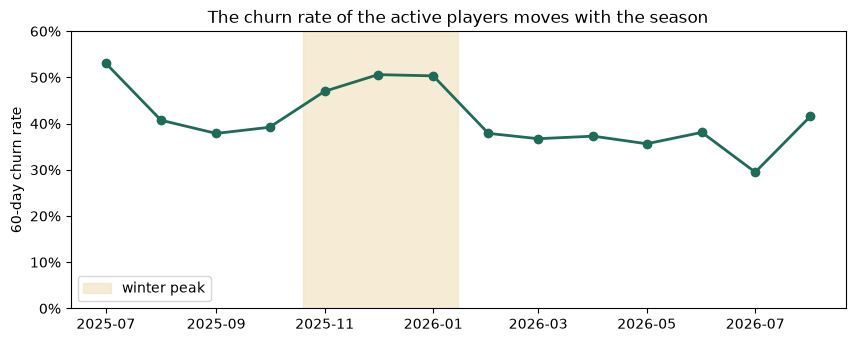

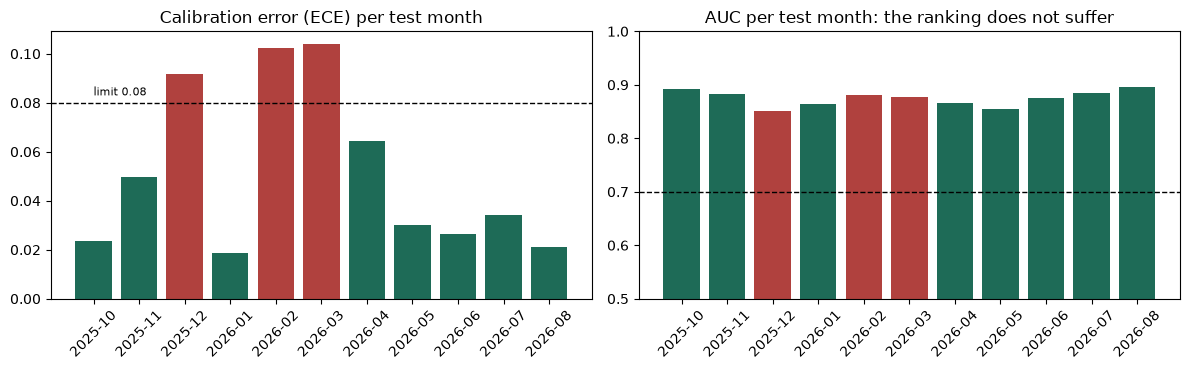

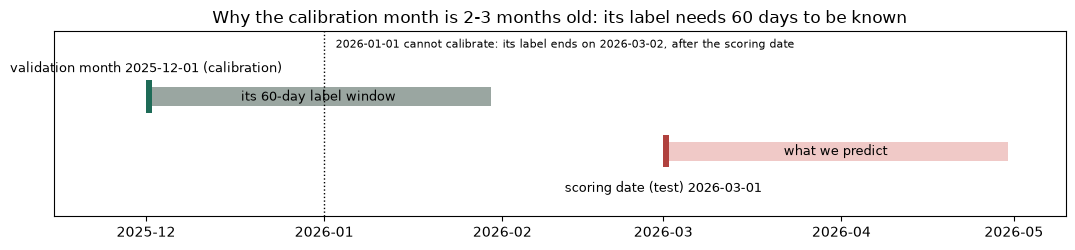

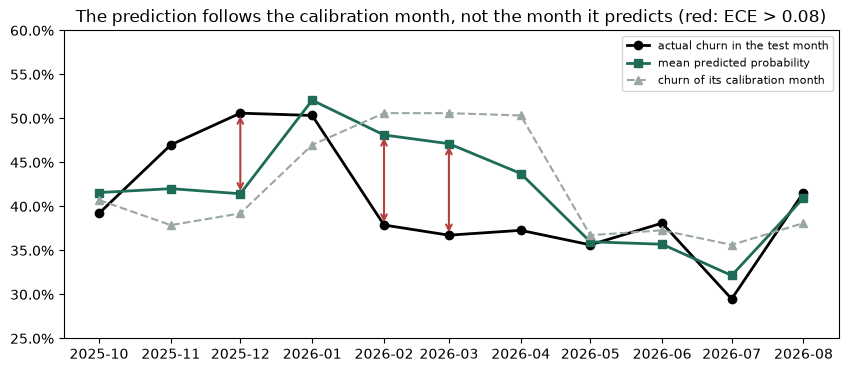

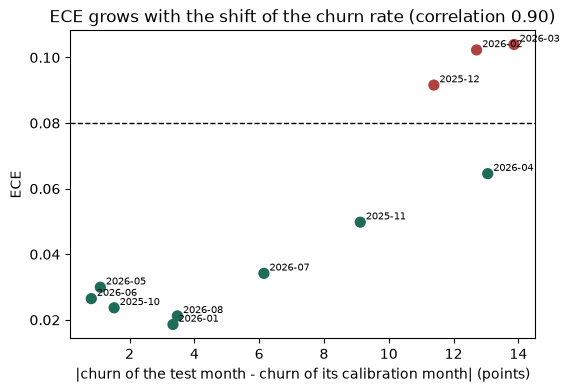

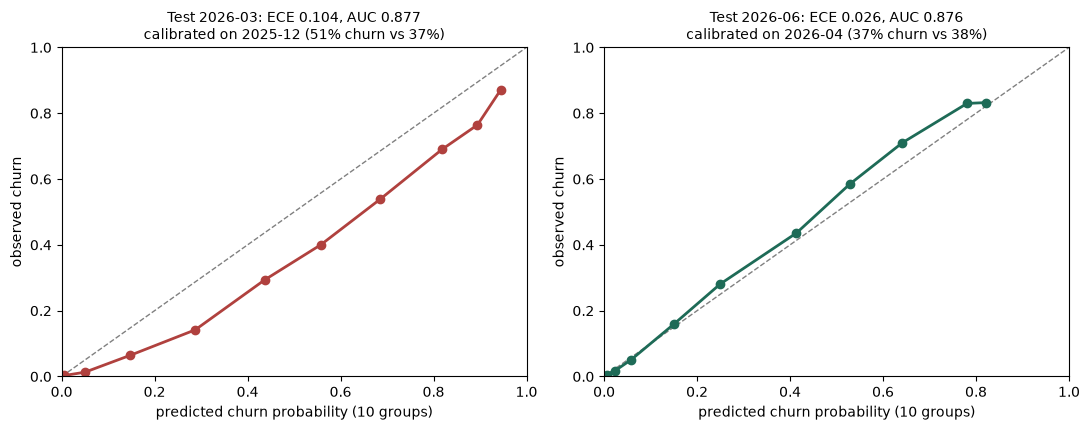

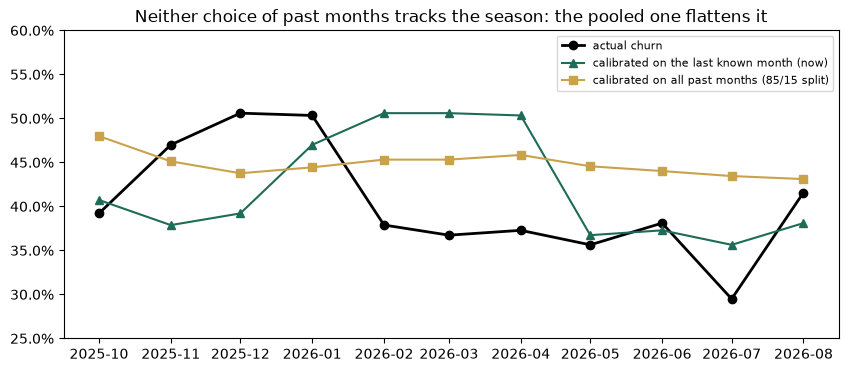

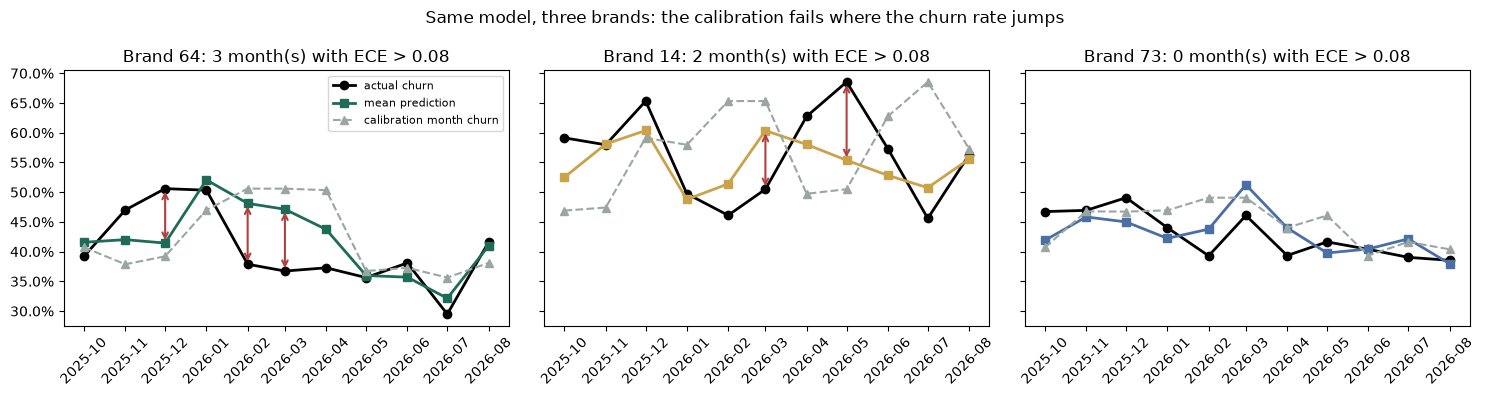

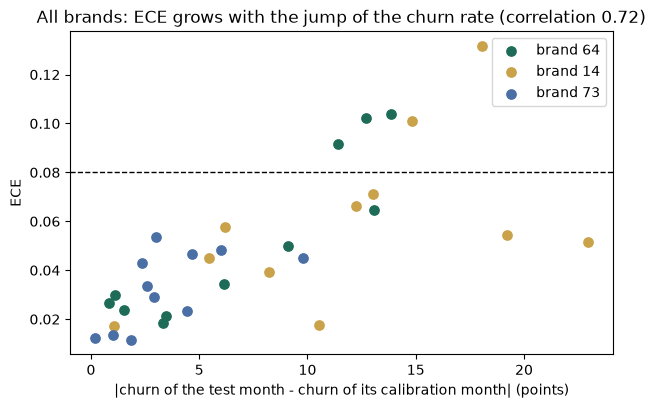

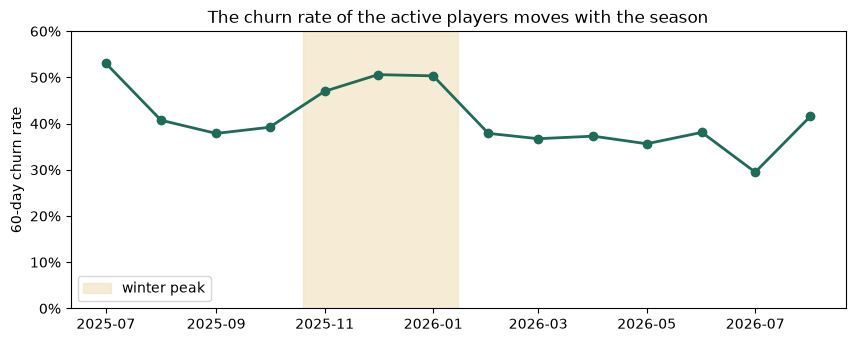

In [ ]:
frames = [pd.read_parquet(p, columns=["cutoff_date", "tenant_id", "player_id", "event_60d"]) for p in sorted(SCENARIOS.glob("*.parquet"))]
players = pd.concat(frames).drop_duplicates(subset=["cutoff_date", "tenant_id", "player_id"])
monthly = (players.groupby("cutoff_date")["event_60d"].agg(["mean", "size"])
           .rename(columns={"mean": "churn_60d", "size": "players"}))
monthly.index = pd.to_datetime(monthly.index)

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.axvspan(pd.Timestamp("2025-10-20"), pd.Timestamp("2026-01-15"), color="#f3e3c3", alpha=.7, label="winter peak")
ax.plot(monthly.index, monthly["churn_60d"], marker="o", color=OK, lw=2)
ax.set_ylim(0, .6); ax.set_ylabel("60-day churn rate"); ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_title("The churn rate of the active players moves with the season"); ax.legend(loc="lower left")
plt.show()

From November to January about **half** of the active players churn; the rest of the year it is 30% to 40% (29.5% in July 2026). The model has to predict a probability whose base level changes by up to 15 points within two months.

## 3. Only the level fails, not the ranking

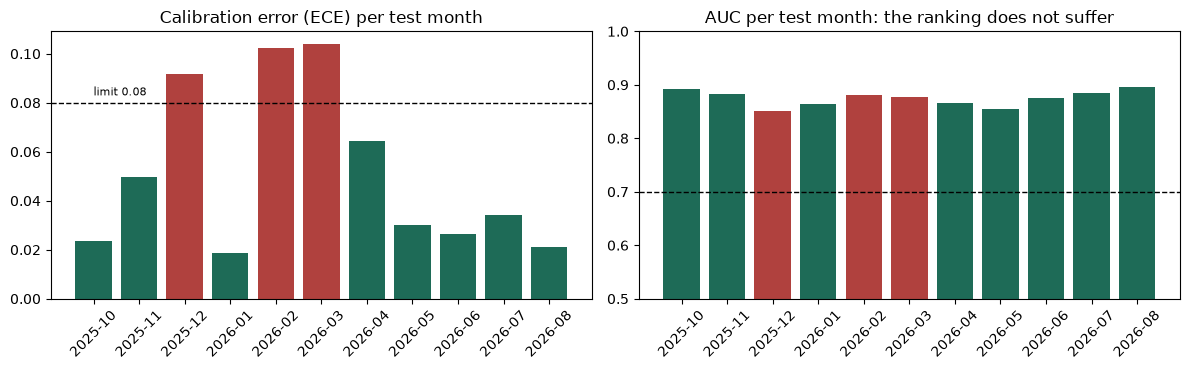

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
labels = bt["test_month"].dt.strftime("%Y-%m")
axes[0].bar(labels, bt["ece"], color=np.where(bt["fails"], FAIL, OK))
axes[0].axhline(ECE_LIMIT, color="black", ls="--", lw=1); axes[0].text(0, ECE_LIMIT + .003, "limit 0.08", fontsize=8)
axes[0].set_title("Calibration error (ECE) per test month"); axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(labels, bt["auc"], color=np.where(bt["fails"], FAIL, OK))
axes[1].set_ylim(.5, 1); axes[1].axhline(.7, color="black", ls="--", lw=1)
axes[1].set_title("AUC per test month: the ranking does not suffer"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

The three failing months (red) keep an AUC of 0.85 to 0.88, like the others: the model still knows **who** is more at risk than whom. What is wrong is **how much**: the probability is shifted for everyone.

## 4. Why the calibration month is 2 to 3 months old

The probability is calibrated on the validation month: the latest month whose 60-day label is already known on the scoring date. A month's label is known 60 days after it, so that month is always at least 2 months back. Example for the test month March 2026:

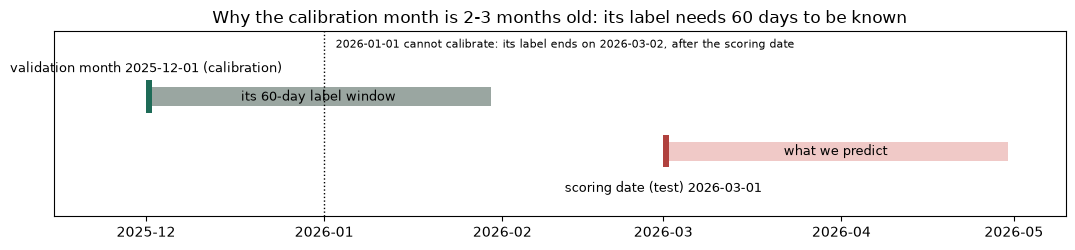

In [29]:
d = lambda s: mdates.date2num(pd.Timestamp(s))  # dates as matplotlib day numbers
c, v = d("2026-03-01"), d("2025-12-01")
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.barh(1, 60, left=v, height=.35, color=GREY); ax.text(v + 30, 1, "its 60-day label window", ha="center", va="center", fontsize=9)
ax.barh(1, 1, left=v, height=.6, color=OK); ax.text(v, 1.45, "validation month 2025-12-01 (calibration)", ha="center", fontsize=9)
ax.barh(0, 60, left=c, height=.35, color="#f0c9c7"); ax.text(c + 30, 0, "what we predict", ha="center", va="center", fontsize=9)
ax.barh(0, 1, left=c, height=.6, color=FAIL); ax.text(c, -.75, "scoring date (test) 2026-03-01", ha="center", fontsize=9)
ax.axvline(d("2026-01-01"), color="black", ls=":", lw=1)
ax.text(d("2026-01-03"), 1.9, "2026-01-01 cannot calibrate: its label ends on 2026-03-02, after the scoring date", ha="left", fontsize=8)
ax.xaxis_date(); ax.set_yticks([]); ax.set_ylim(-1.2, 2.2); ax.set_xlim(d("2025-11-15"), d("2026-05-10"))
ax.set_title("Why the calibration month is 2-3 months old: its label needs 60 days to be known")
plt.tight_layout(); plt.show()

## 5. The prediction follows the calibration month

The black line is what happened; the green one, what the model predicted on average; the dashed grey one, the churn of the month it was calibrated on. Red arrows: the months with ECE > 0.08.

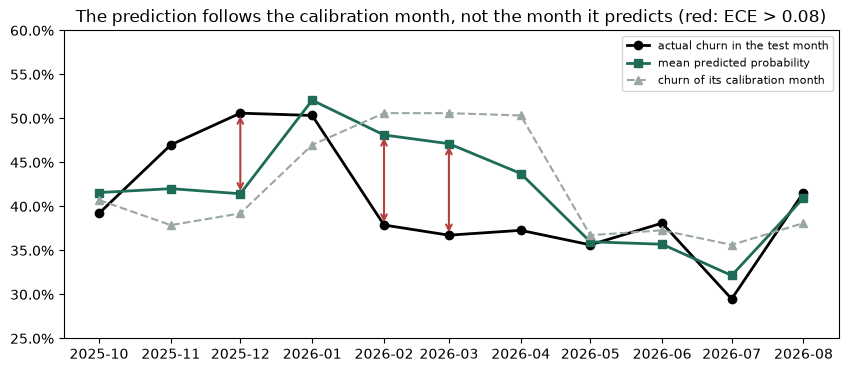

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bt["test_month"], bt["test_churn"], marker="o", color="black", lw=2, label="actual churn in the test month")
ax.plot(bt["test_month"], bt["mean_prediction"], marker="s", color=OK, lw=2, label="mean predicted probability")
ax.plot(bt["test_month"], bt["valid_churn"], marker="^", color=GREY, ls="--", label="churn of its calibration month")
for r in bt[bt["fails"]].itertuples():
    ax.annotate("", xy=(r.test_month, r.test_churn), xytext=(r.test_month, r.mean_prediction),
                arrowprops=dict(arrowstyle="<->", color=FAIL, lw=1.5))
ax.set_ylim(.25, .6); ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); ax.legend(fontsize=8)
ax.set_title("The prediction follows the calibration month, not the month it predicts (red: ECE > 0.08)")
plt.show()

- **December 2025**: calibrated on October (39% churn), it predicted 41%; the winter peak came (51%). Too low.
- **February and March 2026**: calibrated on December, in the peak (51%), they predicted 47% to 48%; churn had gone back to 37% to 38%. Too high.
- In the other months the churn rate did not move much between the calibration month and the test month, and the probability is right.

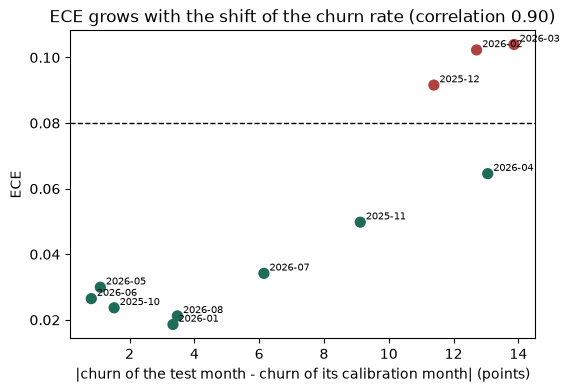

In [31]:
bt["churn_shift"] = (bt["test_churn"] - bt["valid_churn"]).abs()
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(bt["churn_shift"] * 100, bt["ece"], c=np.where(bt["fails"], FAIL, OK), s=50)
for r in bt.itertuples():
    ax.annotate(r.test_month.strftime("%Y-%m"), (r.churn_shift * 100, r.ece), fontsize=7, xytext=(4, 2), textcoords="offset points")
ax.axhline(ECE_LIMIT, color="black", ls="--", lw=1)
ax.set_xlabel("|churn of the test month - churn of its calibration month| (points)"); ax.set_ylabel("ECE")
ax.set_title(f"ECE grows with the shift of the churn rate (correlation {bt['churn_shift'].corr(bt['ece']):.2f})")
plt.show()

The bigger the jump of the churn rate between the calibration month and the test month, the bigger the ECE. That jump explains the failures.

## 6. What it looks like for the players

Reliability curves: predicted probability (10 groups) against observed churn. On the diagonal, the probability is right.

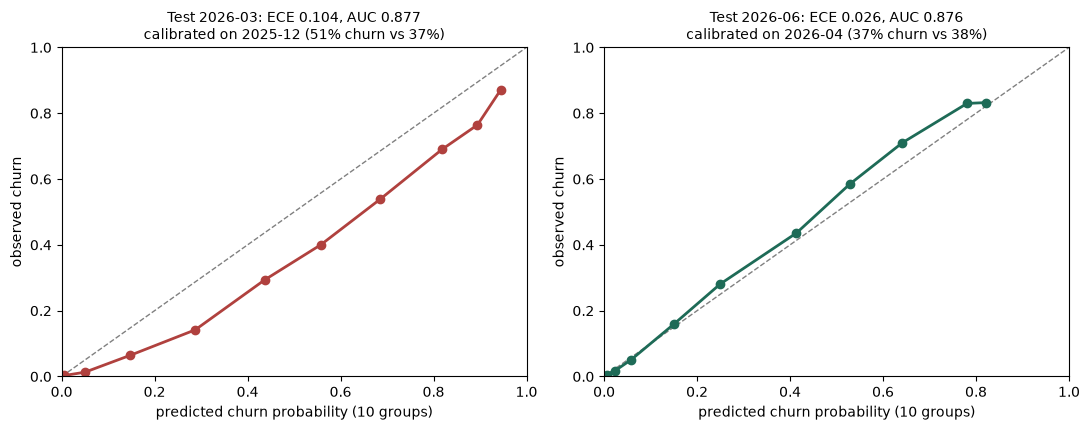

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, month in zip(axes, ("2026-03-01", "2026-06-01")):
    r = bt[bt["test_month"] == month].iloc[0]
    pred = backtest._predictions(r["run_id"])
    observed, predicted = calibration_curve(pred["event_60d"], pred["score"], n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
    ax.plot(predicted, observed, marker="o", color=FAIL if r["fails"] else OK, lw=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel("predicted churn probability (10 groups)"); ax.set_ylabel("observed churn")
    ax.set_title(f"Test {month[:7]}: ECE {r['ece']:.3f}, AUC {r['auc']:.3f}\ncalibrated on {r['valid_month']:%Y-%m} ({r['valid_churn']:.0%} churn vs {r['test_churn']:.0%})", fontsize=10)
plt.tight_layout()
plt.show()

In March 2026 the whole curve sits below the diagonal: every group churned less than predicted, by about 10 points. The shape is still good (higher prediction, higher churn), which is why the AUC does not move. In June 2026 the curve follows the diagonal.

## 7. Would other calibration data fix it?

### Calibrate on all past months (85/15 split by player)

The churn rate the calibration would learn with each choice, against the actual one. "All past months" is the row-weighted mean of every month with a known label, which is what a random 15% of players from all the training months would give.

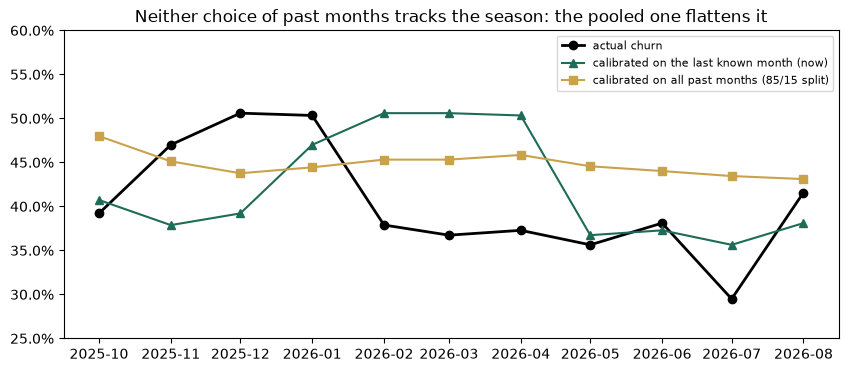

,test_month,test_churn,last_month,all_months_pooled,gap_last_month,gap_all_months_pooled
0,2025-10-01,0.392,0.407,0.480,1.524,8.785
1,2025-11-01,0.470,0.379,0.451,9.120,1.874
2,2025-12-01,0.506,0.392,0.438,11.392,6.830
3,2026-01-01,0.503,0.470,0.444,3.340,5.896
4,2026-02-01,0.379,0.506,0.453,12.710,7.431
5,2026-03-01,0.367,0.506,0.453,13.866,8.587
6,2026-04-01,0.373,0.503,0.458,13.054,8.564
7,2026-05-01,0.356,0.367,0.446,1.098,8.928
8,2026-06-01,0.381,0.373,0.440,0.820,5.916
9,2026-07-01,0.295,0.356,0.434,6.146,13.962


In [33]:
def calibration_reference(test_month, months):
    """Churn rate the calibration would learn: the last month with a known label, or all of them (row-weighted)."""
    known = monthly[monthly.index + pd.Timedelta(60, unit="D") <= test_month]
    pooled = (known["churn_60d"] * known["players"]).sum() / known["players"].sum()
    return known["churn_60d"].iloc[-1], pooled

alt = bt[["test_month", "test_churn"]].copy()
alt[["last_month", "all_months_pooled"]] = [calibration_reference(m, monthly) for m in alt["test_month"]]
for col in ("last_month", "all_months_pooled"):
    alt[f"gap_{col}"] = (alt[col] - alt["test_churn"]).abs() * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alt["test_month"], alt["test_churn"], marker="o", color="black", lw=2, label="actual churn")
ax.plot(alt["test_month"], alt["last_month"], marker="^", color=OK, label="calibrated on the last known month (now)")
ax.plot(alt["test_month"], alt["all_months_pooled"], marker="s", color="#c9a24a", label="calibrated on all past months (85/15 split)")
ax.set_ylim(.25, .6); ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); ax.legend(fontsize=8)
ax.set_title("Neither choice of past months tracks the season: the pooled one flattens it")
plt.show()
alt.round(3)



### Calibrate on the last 3 months (tried on 2026-10-07)

The backtest was run again with `valid_cutoffs: 3` in `configs/backtest.yaml` (validation = the 3 latest months with a known label):

In [34]:
experiment = pd.DataFrame({
    "test_month": ["2025-12", "2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06", "2026-07", "2026-08"],
    "ece_1_valid_month": [0.092, 0.019, 0.102, 0.104, 0.065, 0.030, 0.026, 0.034, 0.021],
    "ece_3_valid_months": [0.076, 0.018, 0.073, 0.069, 0.086, 0.032, 0.021, 0.029, 0.034],
})
experiment

,test_month,ece_1_valid_month,ece_3_valid_months
0,2025-12,0.092,0.076
1,2026-01,0.019,0.018
2,2026-02,0.102,0.073
3,2026-03,0.104,0.069
4,2026-04,0.065,0.086
5,2026-05,0.030,0.032
6,2026-06,0.026,0.021
7,2026-07,0.034,0.029
8,2026-08,0.021,0.034


## 8. Three brands: the same model, different churn patterns

The same pipeline and backtest for brands 64, 14 and 73 (the latest backtest of each, read from MLflow). If the explanation is right, the calibration should fail where the monthly churn rate jumps and hold where it is stable.

In [35]:
BRAND_COLOURS = {64: "#1e6b57", 14: "#c9a24a", 73: "#4a6fa5"}


def backtest_months(brand: int) -> pd.DataFrame:
    """Every test month of the latest rolling-origin backtest of a brand: churn rates, prediction, ECE, AUC."""
    summary = mlflow.search_runs(experiment_names=["whizdom-churn-backtest"], filter_string=f"tags.brand_id = '{brand}'",
                                 order_by=["attributes.start_time DESC"])
    backtest_id = summary[summary["metrics.passed"].notna()].iloc[0]["tags.backtest_id"]
    runs = mlflow.search_runs(
        experiment_names=["whizdom-churn-training"],
        filter_string=f"tags.backtest_id = '{backtest_id}' and tags.role = 'optimised' and params.model_id = 'lightgbm_classifier'")
    return pd.DataFrame({
        "brand": brand,
        "test_month": pd.to_datetime(runs["tags.test_cutoff"]),
        "valid_churn": runs["metrics.valid_churn_rate"],
        "test_churn": runs["metrics.test_churn_rate"],
        "mean_prediction": runs["metrics.test_calibrated_mean_prediction"],
        "ece": runs["metrics.test_calibrated_ece"],
        "auc": runs["metrics.test_calibrated_roc_auc"],
    }).sort_values("test_month")


brands = pd.concat([backtest_months(b) for b in BRAND_COLOURS], ignore_index=True)
brands["churn_shift"] = (brands["test_churn"] - brands["valid_churn"]).abs()
brands["fails"] = brands["ece"] > ECE_LIMIT
summary = brands.groupby("brand").agg(
    churn_min=("test_churn", "min"), churn_max=("test_churn", "max"),
    largest_shift_pts=("churn_shift", lambda s: s.max() * 100), mean_shift_pts=("churn_shift", lambda s: s.mean() * 100),
    worst_ece=("ece", "max"), months_failing=("fails", "sum"), mean_auc=("auc", "mean"), min_auc=("auc", "min"),
).loc[list(BRAND_COLOURS)]
summary.round(3)

,churn_min,churn_max,largest_shift_pts,mean_shift_pts,worst_ece,months_failing,mean_auc,min_auc
brand,,,,,,,,
64,0.295,0.506,13.866,6.959,0.104,3,0.875,0.851
14,0.456,0.685,22.956,11.979,0.132,2,0.871,0.821
73,0.385,0.491,9.778,3.529,0.054,0,0.887,0.863


- **Brand 73** has the most stable churn rate (38% to 49%, 3.5 points of average jump between the calibration month and the test month): **no month above 0.08** (worst 0.054).
- **Brand 64** moves more (30% to 51%, 7 points on average, up to 14): **3 months fail**, all at the turns of the winter peak.
- **Brand 14** moves the most (46% to 69%, 12 points on average, up to 23): **2 months fail**, with the worst ECE of the three (0.132).
- The ranking holds everywhere: mean AUC 0.87 to 0.89, never below 0.82.

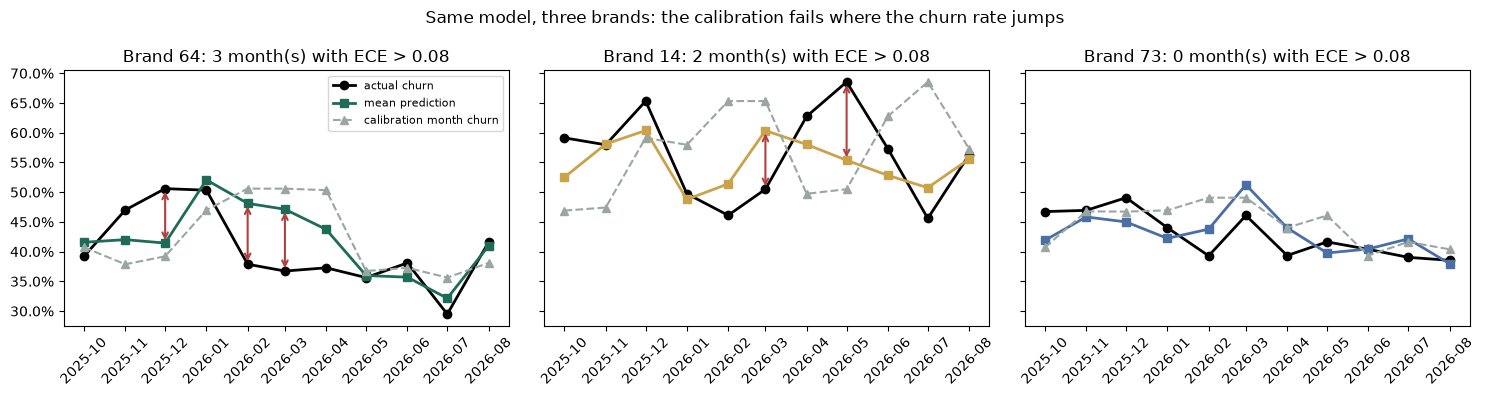

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (brand, rows) in zip(axes, brands.groupby("brand", sort=False)):
    ax.plot(rows["test_month"], rows["test_churn"], marker="o", color="black", lw=2, label="actual churn")
    ax.plot(rows["test_month"], rows["mean_prediction"], marker="s", color=BRAND_COLOURS[brand], lw=2, label="mean prediction")
    ax.plot(rows["test_month"], rows["valid_churn"], marker="^", color=GREY, ls="--", label="calibration month churn")
    for r in rows[rows["fails"]].itertuples():
        ax.annotate("", xy=(r.test_month, r.test_churn), xytext=(r.test_month, r.mean_prediction),
                    arrowprops=dict(arrowstyle="<->", color=FAIL, lw=1.5))
    ax.set_title(f"Brand {brand}: {int(rows['fails'].sum())} month(s) with ECE > {ECE_LIMIT}")
    ax.tick_params(axis="x", rotation=45); ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].legend(fontsize=8)
fig.suptitle("Same model, three brands: the calibration fails where the churn rate jumps")
plt.tight_layout(); plt.show()

The seasonality is not the same in every brand: brand 64 peaks in winter, brand 14 has peaks in December and May. A fixed "winter correction" would not work; the level has to be estimated for each brand.

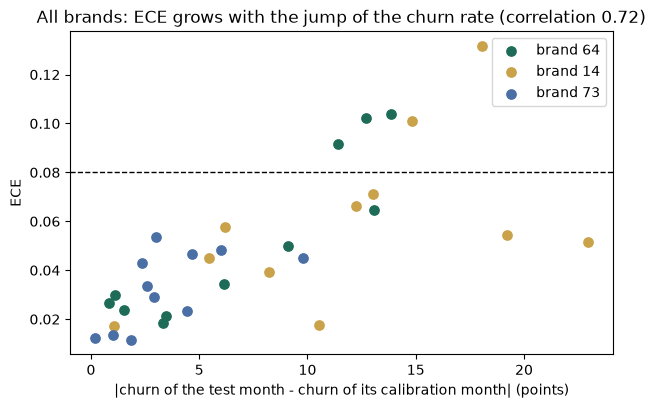

In [37]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for brand, rows in brands.groupby("brand", sort=False):
    ax.scatter(rows["churn_shift"] * 100, rows["ece"], color=BRAND_COLOURS[brand], s=45, label=f"brand {brand}")
ax.axhline(ECE_LIMIT, color="black", ls="--", lw=1)
ax.set_xlabel("|churn of the test month - churn of its calibration month| (points)"); ax.set_ylabel("ECE")
ax.set_title(f"All brands: ECE grows with the jump of the churn rate (correlation {brands['churn_shift'].corr(brands['ece']):.2f})")
ax.legend(); plt.show()